### Блок 5. Волатильность и стабильность поставок

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory


#### Подготовка и вспомогательный функции 

In [2]:
vol_data = pd.read_excel('data/final_data.xlsx')
vol_data["rep_date"] = pd.to_datetime(vol_data["rep_date"])
vol_data = vol_data.sort_values(["rep_date", "country", "hs"]).reset_index(drop=True)

shock_date = pd.Timestamp("2022-02-01")

save_dir = "figures/eda_block_5"
os.makedirs(save_dir, exist_ok=True)

In [3]:
def human_format(x, pos):
    abs_x = abs(x)
    if abs_x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif abs_x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif abs_x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

def apply_style(ax, title, ylabel=None, xlabel=None, shade_post=False, top=False, post_sanctions=True):
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12, labelpad=15)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12, labelpad=15)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)
    ax.tick_params(axis="both", labelsize=11)

    if shade_post:
        # правая граница именно текущей оси
        x_left = mdates.date2num(shock_date)
        x_right = ax.get_xlim()[1]

        # красим до конца графика
        ax.axvspan(x_left, x_right, alpha=0.08, color="#B22222")
        ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

        # X в координатах данных, Y в долях оси
        trans = blended_transform_factory(ax.transData, ax.transAxes)

        # подпись чуть левее правого края красной зоны
        x_text = x_right - 0.02 * (x_right - x_left)

        if top:
            if post_sanctions:
                ax.text(
                    x_text, 0.94,
                    "Постсанкционный период",
                    transform=trans,
                    color="#8B0000",
                    fontsize=10,
                    ha="right",
                    va="top",
                    linespacing=1.0
                )
        else: 
            if post_sanctions: 
                ax.text(
                    x_right - 0.1 * (x_right - x_left), 0.04,
                    "Постсанкционный период",
                    transform=trans,
                    color="#8B0000",
                    fontsize=10,
                    ha="right",
                    va="bottom",
                    linespacing=1.0
                )

def save_figure(fig, filename):
    fig.savefig(os.path.join(save_dir, f"{filename}.png"), dpi=400, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [4]:
# ОБЩИЙ МЕСЯЧНЫЙ РЯД

monthly_total = (
    vol_data.groupby("rep_date", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "total_value"})
    .sort_values("rep_date")
)

monthly_total["period"] = np.where(
    monthly_total["rep_date"] < shock_date,
    "2019–2021",
    "2022–2025"
)

# Абсолютное месячное изменение
monthly_total["abs_mom_change"] = monthly_total["total_value"].diff().abs()

# Темпы роста
monthly_total["mom_growth_pct"] = monthly_total["total_value"].pct_change() * 100
monthly_total["yoy_growth_pct"] = monthly_total["total_value"].pct_change(12) * 100

# Rolling volatility по уровням
monthly_total["rolling_std_12"] = monthly_total["total_value"].rolling(window=12, min_periods=6).std()
monthly_total["rolling_mean_12"] = monthly_total["total_value"].rolling(window=12, min_periods=6).mean()
monthly_total["rolling_cv_12"] = monthly_total["rolling_std_12"] / monthly_total["rolling_mean_12"] * 100

# Rolling volatility по годовым темпам роста
monthly_total["rolling_std_yoy_6"] = monthly_total["yoy_growth_pct"].rolling(window=6, min_periods=4).std()

display(monthly_total.head(15))

,rep_date,total_value,period,abs_mom_change,mom_growth_pct,yoy_growth_pct,rolling_std_12,rolling_mean_12,rolling_cv_12,rolling_std_yoy_6
0,2019-01-01,2.631455e+08,2019–2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,2.988145e+08,2019–2021,3.566902e+07,13.554867,NaN,NaN,NaN,NaN,NaN
2,2019-03-01,3.797893e+08,2019–2021,8.097483e+07,27.098696,NaN,NaN,NaN,NaN,NaN
3,2019-04-01,3.531492e+08,2019–2021,2.664010e+07,-7.014442,NaN,NaN,NaN,NaN,NaN
4,2019-05-01,3.480698e+08,2019–2021,5.079355e+06,-1.438303,NaN,NaN,NaN,NaN,NaN
5,2019-06-01,3.833716e+08,2019–2021,3.530173e+07,10.142141,NaN,4.748489e+07,3.377233e+08,14.060295,NaN
6,2019-07-01,4.137622e+08,2019–2021,3.039064e+07,7.927203,NaN,5.200962e+07,3.485860e+08,14.920168,NaN
7,2019-08-01,3.753383e+08,2019–2021,3.842391e+07,-9.286470,NaN,4.907171e+07,3.519301e+08,13.943597,NaN
8,2019-09-01,4.162637e+08,2019–2021,4.092536e+07,10.903593,NaN,5.066455e+07,3.590782e+08,14.109614,NaN
9,2019-10-01,4.705612e+08,2019–2021,5.429755e+07,13.044027,NaN,5.936777e+07,3.702265e+08,16.035526,NaN


#### # ГРАФИК 1. ROLLING STD ОБЩЕГО ИМПОРТА

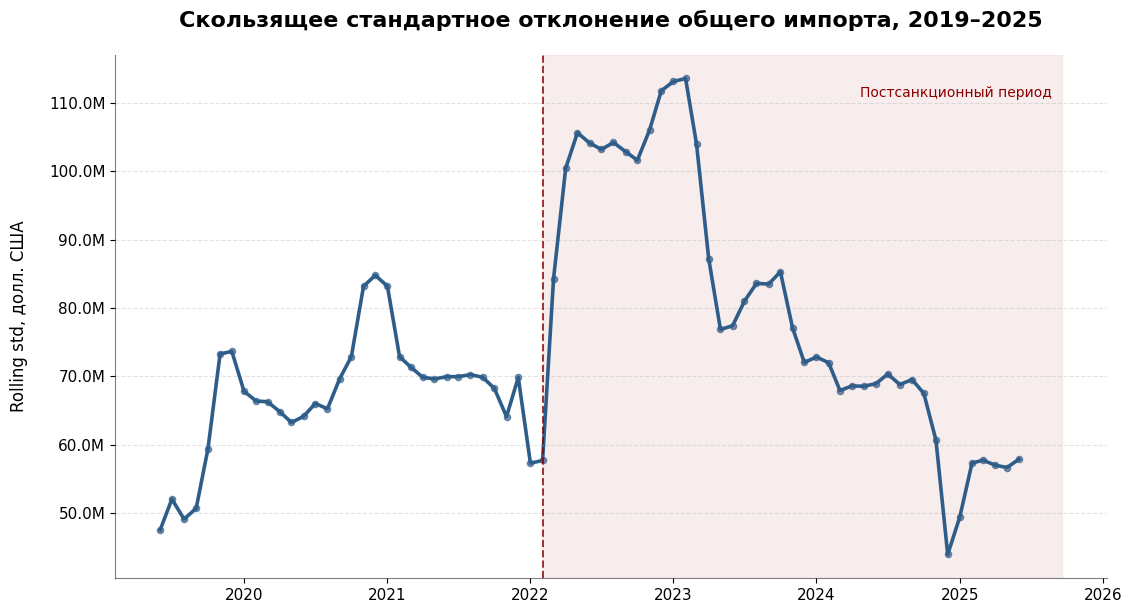

In [7]:
fig, ax = plt.subplots(figsize=(12.8, 6.8))

ax.plot(
    monthly_total["rep_date"],
    monthly_total["rolling_std_12"],
    color="#2F5D8A",
    linewidth=2.6
)

ax.scatter(
    monthly_total["rep_date"],
    monthly_total["rolling_std_12"],
    color="#2F5D8A",
    s=20,
    alpha=0.65
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(FuncFormatter(human_format))

apply_style(
    ax,
    title="Скользящее стандартное отклонение общего импорта, 2019–2025",
    ylabel="Rolling std, долл. США",
    shade_post=True, top=True
)

save_figure(fig, "01_rolling_std_total_import")

График rolling standard deviation показывает, что после 2022 года изменчивость общего стоимостного импорта сначала резко возрастает. Если в 2019–2021 гг. скользящее стандартное отклонение в основном находилось примерно в диапазоне 50–85 млн долл. США, то в 2022–начале 2023 гг. оно поднимается выше 100 млн долл. США. Это означает, что в первые постсанкционные кварталы месячные объемы импорта стали колебаться значительно сильнее, чем в докризисный период. Далее волатильность постепенно снижается, однако сам постсанкционный этап уже не выглядит столь устойчивым, как прежний: система сначала входит в фазу сильной турбулентности, а затем лишь частично стабилизируется. Тем самым график подтверждает, что санкционный шок сопровождался заметным ухудшением краткосрочной стабильности поставок.

#### ГРАФИК 2. ROLLING COEFFICIENT OF VARIATION

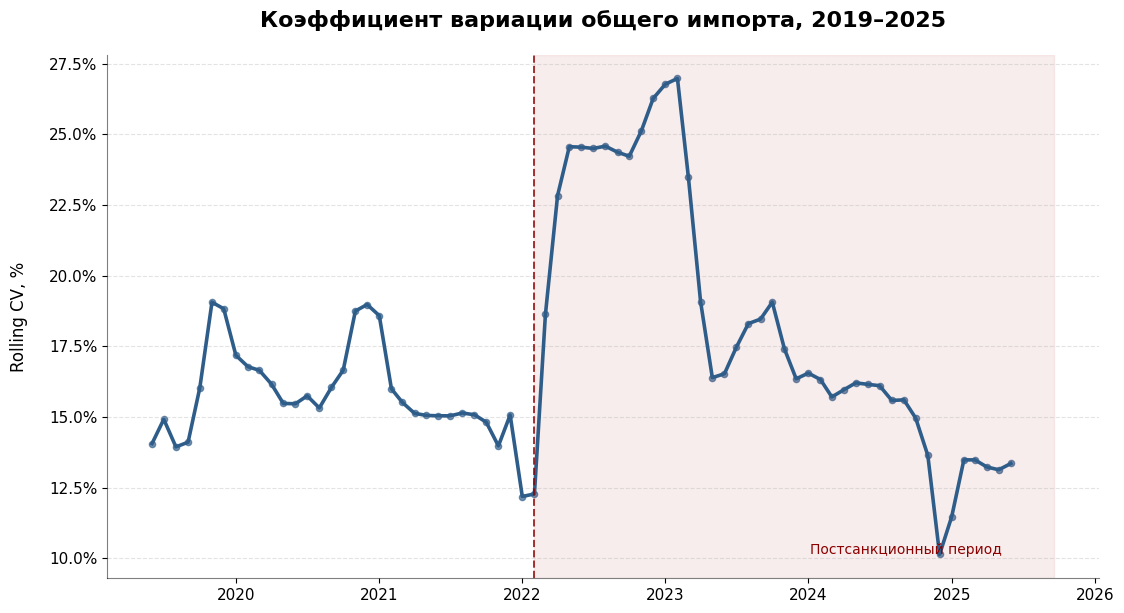

In [8]:
fig, ax = plt.subplots(figsize=(12.8, 6.8))

ax.plot(
    monthly_total["rep_date"],
    monthly_total["rolling_cv_12"],
    color="#2F5D8A",
    linewidth=2.6
)

ax.scatter(
    monthly_total["rep_date"],
    monthly_total["rolling_cv_12"],
    color="#2F5D8A",
    s=20,
    alpha=0.65
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter())

apply_style(
    ax,
    title="Коэффициент вариации общего импорта, 2019–2025",
    ylabel="Rolling CV, %",
    shade_post=True
)

save_figure(fig, "02_rolling_cv_total_import")

Коэффициент вариации позволяет оценить волатильность относительно среднего уровня импорта, и в этом смысле он особенно показателен. До 2022 года значение rolling CV в основном держалось около 14–19%, тогда как после шока поднималось до 24–27%. Следовательно, дело не только в росте абсолютных колебаний в долларах, но и в том, что сами колебания стали больше по отношению к среднему объему импорта. В дальнейшем коэффициент вариации снижается, но резкий скачок в 2022–2023 гг. указывает на переход системы в существенно более нестабильный режим. Таким образом, график подтверждает, что постсанкционный период сопровождался именно относительным усилением нестабильности, а не просто изменением масштабов поставок.

#### ГРАФИК 3. ВОЛАТИЛЬНОСТЬ ПО BLOC-ГРУППАМ

In [9]:
vol_data[["unfriendly", "brics", "cis"]] = vol_data[["unfriendly", "brics", "cis"]].fillna(0).astype(int)

vol_data["bloc"] = np.select(
    [
        vol_data["unfriendly"].eq(1),
        vol_data["brics"].eq(1),
        vol_data["cis"].eq(1)
    ],
    [
        "Недружественные",
        "БРИКС",
        "СНГ"
    ],
    default="Прочие"
)

bloc_order = ["Недружественные", "БРИКС", "СНГ", "Прочие"]

bloc_colors = {
    "Недружественные": "#CD853F",
    "БРИКС": "#2F5D8A", 
    "СНГ": "#2E8B57",
    "Прочие": "#CD5C5C"
}

# Месячный импорт по bloc
bloc_month = (
    vol_data.groupby(["rep_date", "bloc"], as_index=False)["value"]
    .sum()
    .sort_values(["bloc", "rep_date"])
)

# Годовые темпы роста по bloc
bloc_month["yoy_growth_pct"] = (
    bloc_month.groupby("bloc")["value"]
    .pct_change(12) * 100
)

# Скользящая волатильность YoY
bloc_month["rolling_std_yoy_6"] = (
    bloc_month.groupby("bloc")["yoy_growth_pct"]
    .transform(lambda x: x.rolling(window=6, min_periods=4).std())
)

display(bloc_month.head(20))

,rep_date,bloc,value,yoy_growth_pct,rolling_std_yoy_6
0,2019-01-01,БРИКС,2.826360e+07,NaN,NaN
4,2019-02-01,БРИКС,2.041678e+07,NaN,NaN
8,2019-03-01,БРИКС,2.936766e+07,NaN,NaN
12,2019-04-01,БРИКС,2.979400e+07,NaN,NaN
16,2019-05-01,БРИКС,3.107723e+07,NaN,NaN
20,2019-06-01,БРИКС,3.002751e+07,NaN,NaN
24,2019-07-01,БРИКС,3.360183e+07,NaN,NaN
28,2019-08-01,БРИКС,3.295076e+07,NaN,NaN
32,2019-09-01,БРИКС,3.761438e+07,NaN,NaN
36,2019-10-01,БРИКС,3.708228e+07,NaN,NaN


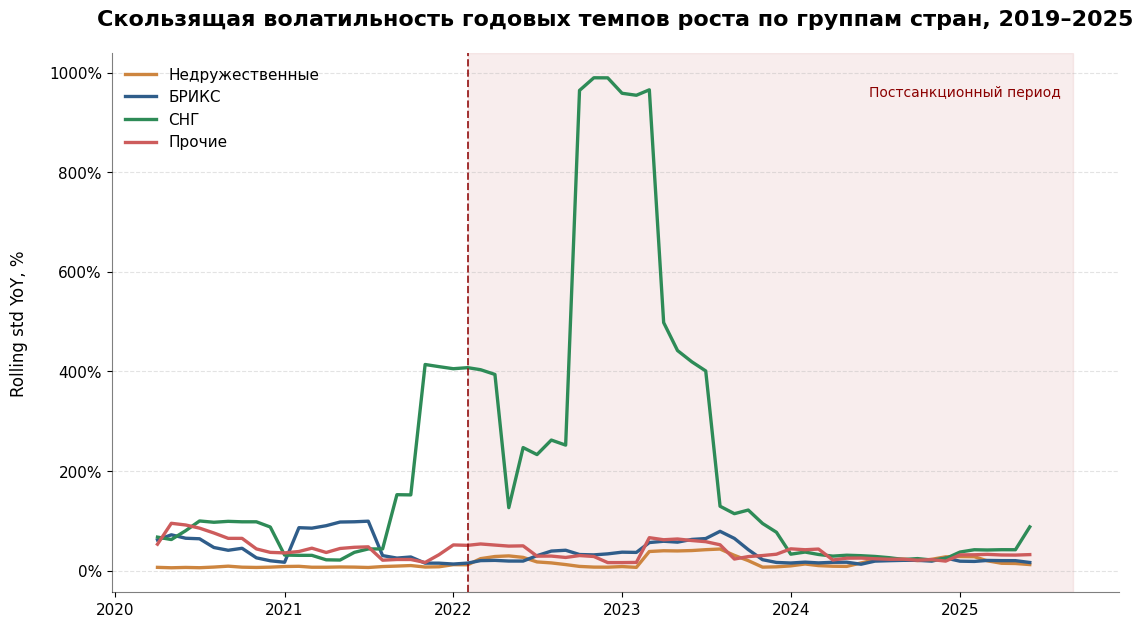

In [11]:
fig, ax = plt.subplots(figsize=(13, 7))

for bloc in bloc_order:
    temp = bloc_month[bloc_month["bloc"] == bloc]
    ax.plot(
        temp["rep_date"],
        temp["rolling_std_yoy_6"],
        linewidth=2.4,
        color=bloc_colors[bloc],
        label=bloc
    )

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter())

apply_style(
    ax,
    title="Скользящая волатильность годовых темпов роста по группам стран, 2019–2025",
    ylabel="Rolling std YoY, %",
    shade_post=True, top=True
)

ax.legend(frameon=False, fontsize=11, loc="upper left")

save_figure(fig, "03_bloc_rolling_volatility_yoy")

На уровне bloc-групп рост нестабильности оказался неодинаковым. Наиболее выраженные всплески наблюдаются у стран СНГ: их rolling volatility YoY после 2022 года достигает экстремально высоких значений, что указывает на очень резкие колебания годовых темпов роста и, вероятно, на эпизодический характер части поставок или эффект низкой базы. У БРИКС, недружественных и прочих стран волатильность также увеличивается, но в гораздо более умеренной степени. Для БРИКС и недружественных стран динамика выглядит более управляемой, хотя и более нестабильной, чем до 2022 года. Это означает, что усиление общей волатильности импорта было вызвано неравномерно: наиболее сильная нестабильность пришлась на те направления, которые либо начали играть новую роль в схемах поставок, либо характеризовались меньшим исходным масштабом и потому более чувствительно реагировали на отдельные сделки.

#### ГРАФИК 4. ABSOLUTE MONTH-TO-MONTH CHANGE: PRE VS POST

C:\Users\Admin\AppData\Local\Temp\ipykernel_64464\588360371.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


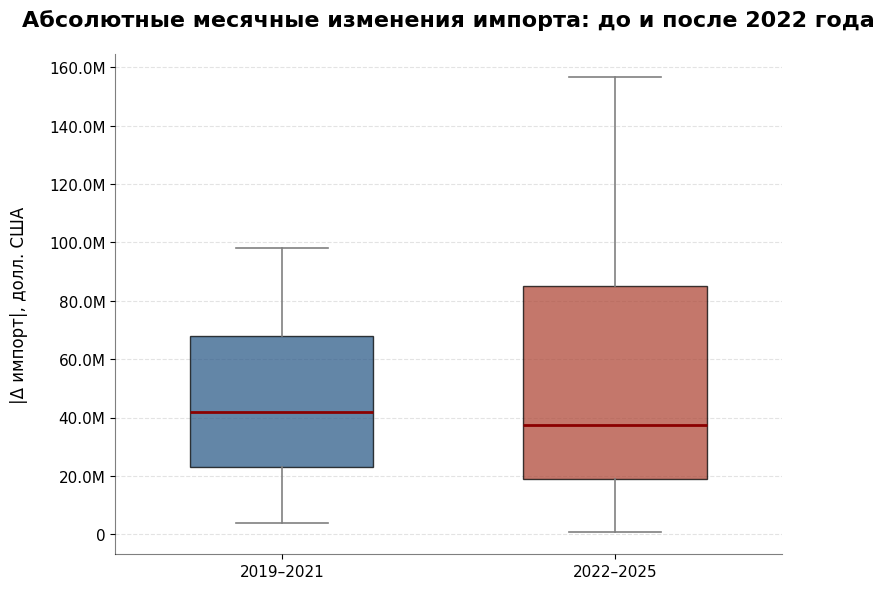

In [12]:
box_data = [
    monthly_total.loc[monthly_total["period"] == "2019–2021", "abs_mom_change"].dropna(),
    monthly_total.loc[monthly_total["period"] == "2022–2025", "abs_mom_change"].dropna()
]

fig, ax = plt.subplots(figsize=(8.6, 6.5))

bp = ax.boxplot(
    box_data,
    patch_artist=True,
    labels=["2019–2021", "2022–2025"],
    showfliers=False,
    widths=0.55
)

box_colors = ["#2F5D8A", "#B04A3A"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for median in bp["medians"]:
    median.set(color="#8B0000", linewidth=2)

for whisker in bp["whiskers"]:
    whisker.set(color="gray", linewidth=1.2)

for cap in bp["caps"]:
    cap.set(color="gray", linewidth=1.2)

ax.yaxis.set_major_formatter(FuncFormatter(human_format))

apply_style(
    ax,
    title="Абсолютные месячные изменения импорта: до и после 2022 года",
    ylabel="|Δ импорт|, долл. США"
)

save_figure(fig, "04_abs_mom_change_boxplot_pre_post")

Boxplot абсолютных месячных изменений показывает, что в постсанкционный период распределение |Δ импорта| стало более растянутым. Хотя медиана абсолютного изменения изменилась незначительно и даже выглядит немного ниже, верхняя часть распределения после 2022 года стала заметно шире: верхний квартиль и верхние “усы” расположены выше, чем в 2019–2021 гг. Это означает, что в среднем система по-прежнему переживает сопоставимые типичные колебания, но крупные месячные скачки — как вверх, так и вниз — стали происходить чаще и стали сильнее. Иными словами, после 2022 года импорт не обязательно менялся сильнее в каждом месяце, но крупные отклонения стали более вероятными, что и отражает рост нестабильности.

#### ГРАФИК 5. РАСПРЕДЕЛЕНИЕ YoY GROWTH PRE VS POST

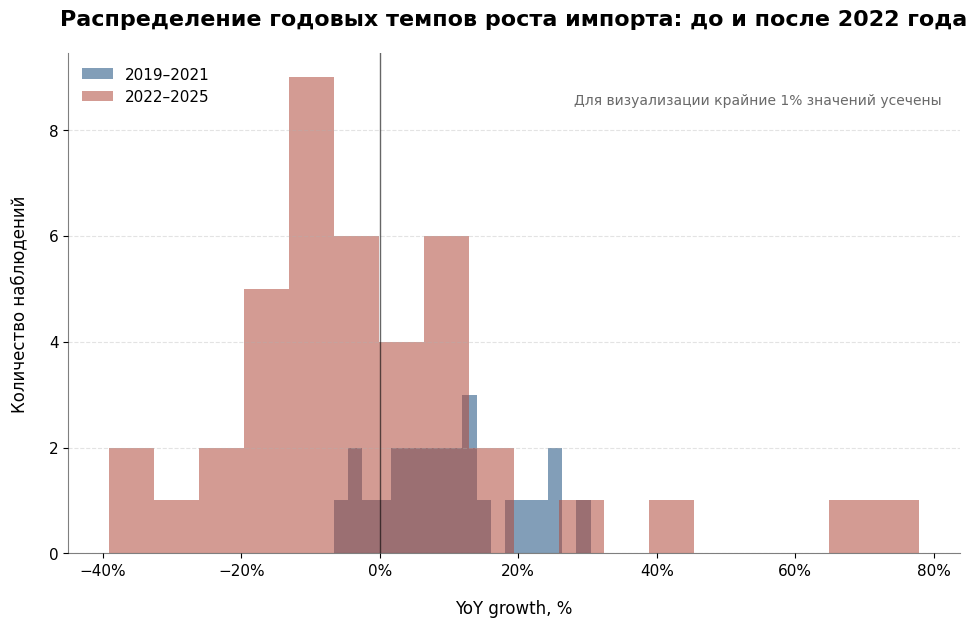

In [13]:
plot_yoy = monthly_total.dropna(subset=["yoy_growth_pct"]).copy()

# Для визуализации ограничим экстремальные хвосты только на графике
low_q = plot_yoy["yoy_growth_pct"].quantile(0.01)
high_q = plot_yoy["yoy_growth_pct"].quantile(0.99)

plot_yoy["yoy_plot"] = plot_yoy["yoy_growth_pct"].clip(lower=low_q, upper=high_q)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

pre = plot_yoy.loc[plot_yoy["period"] == "2019–2021", "yoy_plot"]
post = plot_yoy.loc[plot_yoy["period"] == "2022–2025", "yoy_plot"]

ax.hist(pre, bins=18, alpha=0.60, color="#2F5D8A", label="2019–2021")
ax.hist(post, bins=18, alpha=0.55, color="#B04A3A", label="2022–2025")

ax.axvline(0, color="black", linewidth=1.0, alpha=0.6)
ax.xaxis.set_major_formatter(PercentFormatter())

apply_style(
    ax,
    title="Распределение годовых темпов роста импорта: до и после 2022 года",
    xlabel="YoY growth, %",
    ylabel="Количество наблюдений"
)

ax.legend(frameon=False, fontsize=11)

ax.text(
    0.98, 0.92,
    "Для визуализации крайние 1% значений усечены",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color="dimgray"
)

save_figure(fig, "05_yoy_growth_distribution_pre_post")

Сравнение распределений YoY growth показывает, что после 2022 года динамика импорта стала значительно более разбросанной и асимметричной. Докризисное распределение в целом сосредоточено в более узком диапазоне умеренных положительных значений, тогда как в постсанкционный период наблюдения гораздо чаще уходят как в глубокую отрицательную область, так и в высокие положительные значения. Это отражает чередование сильных падений и последующих восстановлений, причем существенная часть положительных темпов роста после 2022 года, вероятно, связана с эффектом низкой базы. Таким образом, график подтверждает, что постсанкционный режим характеризуется не просто снижением или ростом, а более “неровной” динамикой, в которой усиливаются и отрицательные, и положительные отклонения от среднего поведения.

In [14]:
# HS-МЕСЯЧНЫЕ РЯДЫ

hs_month = (
    vol_data.groupby(["rep_date", "hs"], as_index=False)["value"]
    .sum()
    .sort_values(["hs", "rep_date"])
)

hs_month["period"] = np.where(
    hs_month["rep_date"] < shock_date,
    "2019–2021",
    "2022–2025"
)

hs_month["yoy_growth_pct"] = (
    hs_month.groupby("hs")["value"]
    .pct_change(12) * 100
)

hs_month["abs_yoy_growth_pct"] = hs_month["yoy_growth_pct"].abs()

display(hs_month.head(20))

,rep_date,hs,value,period,yoy_growth_pct,abs_yoy_growth_pct
0,2019-01-01,9018,9.133090e+07,2019–2021,NaN,NaN
9,2019-02-01,9018,1.117062e+08,2019–2021,NaN,NaN
18,2019-03-01,9018,1.373245e+08,2019–2021,NaN,NaN
27,2019-04-01,9018,1.304719e+08,2019–2021,NaN,NaN
36,2019-05-01,9018,1.392405e+08,2019–2021,NaN,NaN
45,2019-06-01,9018,1.480020e+08,2019–2021,NaN,NaN
54,2019-07-01,9018,1.754841e+08,2019–2021,NaN,NaN
63,2019-08-01,9018,1.500754e+08,2019–2021,NaN,NaN
72,2019-09-01,9018,1.789783e+08,2019–2021,NaN,NaN
81,2019-10-01,9018,1.808767e+08,2019–2021,NaN,NaN


#### ГРАФИК 6. СРЕДНЯЯ ABS YoY ВОЛАТИЛЬНОСТЬ ПО HS

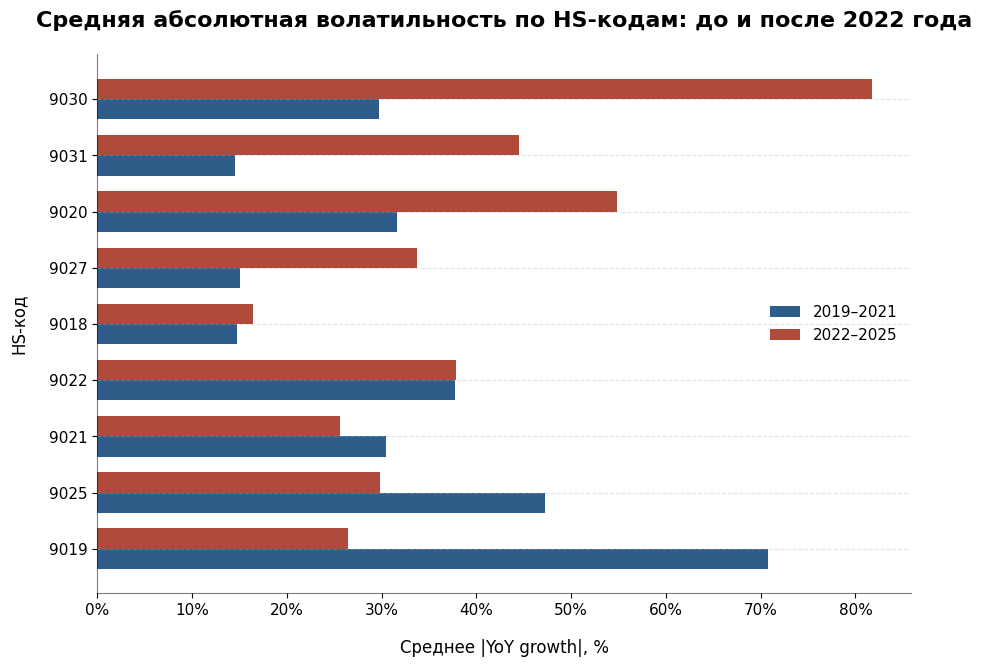

In [16]:
hs_vol_summary = (
    hs_month.groupby(["hs", "period"], as_index=False)["abs_yoy_growth_pct"]
    .mean()
)

hs_vol_wide = (
    hs_vol_summary.pivot(index="hs", columns="period", values="abs_yoy_growth_pct")
    .reset_index()
)

hs_vol_wide["delta"] = hs_vol_wide["2022–2025"] - hs_vol_wide["2019–2021"]
hs_vol_wide = hs_vol_wide.sort_values("delta", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 7))

y = np.arange(len(hs_vol_wide))
bar_h = 0.36

ax.barh(
    y - bar_h / 2,
    hs_vol_wide["2019–2021"],
    height=bar_h,
    color="#2F5D8A",
    label="2019–2021"
)

ax.barh(
    y + bar_h / 2,
    hs_vol_wide["2022–2025"],
    height=bar_h,
    color="#B04A3A",
    label="2022–2025"
)

ax.set_yticks(y)
ax.set_yticklabels(hs_vol_wide["hs"].astype(str))
ax.xaxis.set_major_formatter(PercentFormatter())

apply_style(
    ax,
    title="Средняя абсолютная волатильность по HS-кодам: до и после 2022 года",
    xlabel="Среднее |YoY growth|, %",
    ylabel="HS-код"
)

ax.legend(frameon=False, fontsize=11, loc="center right")

save_figure(fig, "06_abs_yoy_volatility_hs_pre_post")

Сравнение средней абсолютной волатильности по HS-кодам показывает, что влияние санкционного шока на стабильность поставок было гетерогенным по товарным категориям. Наиболее заметный рост |YoY growth| после 2022 года наблюдается по кодам 9030, 9031 и 9020, что означает существенное усиление нестабильности именно в этих сегментах медицинского оборудования. По 9027 рост также присутствует, хотя и в меньшей степени. Напротив, по 9019, 9025 и 9021 средняя абсолютная волатильность после 2022 года снижается, что может говорить либо о более устойчивой адаптации поставок, либо о сокращении амплитуды колебаний после первоначальной перестройки. По 9022 изменения минимальны, то есть эта категория выглядит относительно стабильной по сравнению с остальными. В целом график подтверждает, что санкционный эффект на устойчивость импорта был не универсальным, а сильно зависел от конкретной товарной группы.

#### ГРАФИК 7. HEATMAP ABS YoY GROWTH ПО HS И МЕСЯЦАМ

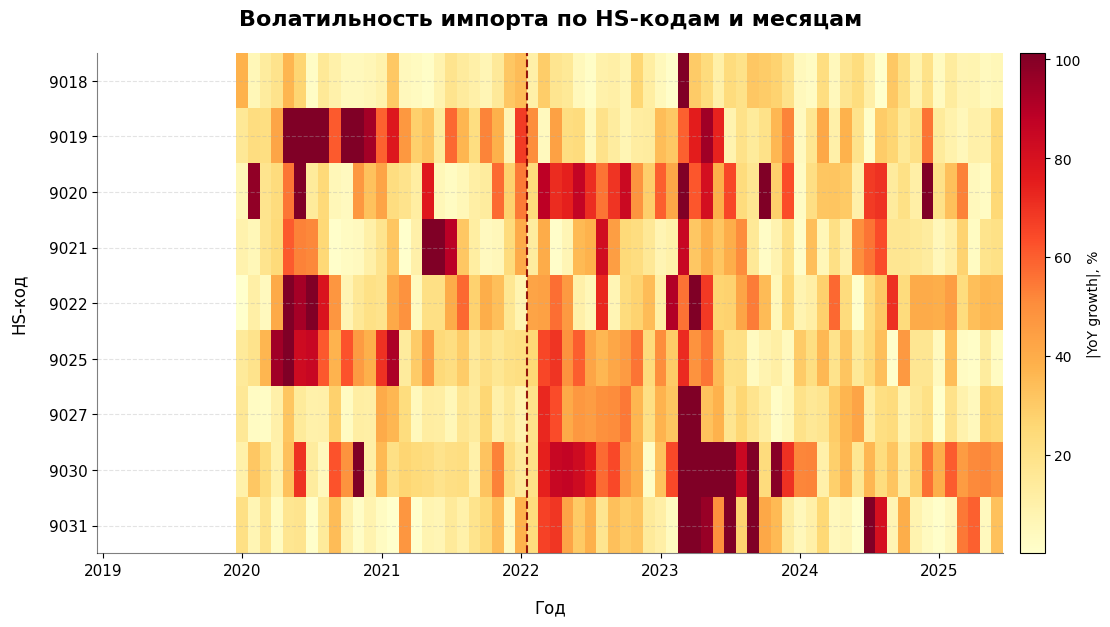

In [17]:
heatmap_vol = (
    hs_month.pivot(index="hs", columns="rep_date", values="abs_yoy_growth_pct")
    .sort_index()
)

# Ограничим хвосты только для визуализации
cap_val = np.nanpercentile(heatmap_vol.values, 95)
heatmap_plot = heatmap_vol.clip(upper=cap_val)

fig, ax = plt.subplots(figsize=(14, 6.5))

im = ax.imshow(
    heatmap_plot,
    aspect="auto",
    cmap="YlOrRd"
)

ax.set_yticks(np.arange(len(heatmap_plot.index)))
ax.set_yticklabels(heatmap_plot.index.astype(str), fontsize=10)

date_cols = heatmap_plot.columns
year_positions = [i for i, d in enumerate(date_cols) if d.month == 1]
year_labels = [str(date_cols[i].year) for i in year_positions]

ax.set_xticks(year_positions)
ax.set_xticklabels(year_labels, fontsize=10)

apply_style(
    ax,
    title="Волатильность импорта по HS-кодам и месяцам",
    ylabel="HS-код",
    xlabel="Год"
)

shock_idx = np.where(date_cols >= shock_date)[0][0]
ax.axvline(shock_idx - 0.5, color="#8B0000", linestyle="--", linewidth=1.5, alpha=0.9)

cbar = fig.colorbar(im, ax=ax, pad=0.015)
cbar.ax.set_ylabel("|YoY growth|, %", fontsize=10)

save_figure(fig, "07_abs_yoy_heatmap_hs_month")

Heatmap по HS и месяцам позволяет увидеть не только различия между товарными категориями, но и время появления основных всплесков нестабильности. После 2022 года наиболее насыщенные зоны наблюдаются прежде всего по кодам 9030, 9031 и 9020, причем особенно сильные эпизоды приходятся на 2022–2024 гг. Это указывает на то, что именно в первые годы после санкционного шока данные категории переживали наиболее резкие колебания годовых темпов роста. По другим кодам всплески менее интенсивны и более фрагментарны, а в некоторых случаях волатильность распределена относительно равномерно. Такой рисунок позволяет сделать вывод, что постсанкционная нестабильность носила не только общий, но и выраженно сегментированный характер: отдельные виды медицинского оборудования оказались заметно более чувствительными к перестройке логистики, поставщиков и каналов импорта, чем другие.

#### ТАБЛИЦА 1. СВОДКА ПО ВОЛАТИЛЬНОСТИ ДО И ПОСЛЕ 2022 ГОДА

In [19]:
vol_summary = (
    monthly_total.groupby("period", as_index=False)
    .agg(
        std_total_value=("total_value", "std"),
        mean_abs_mom_change=("abs_mom_change", "mean"),
        std_yoy_growth=("yoy_growth_pct", "std"),
        mean_abs_yoy_growth=("yoy_growth_pct", lambda x: np.nanmean(np.abs(x)))
    )
)

vol_summary

,period,std_total_value,mean_abs_mom_change,std_yoy_growth,mean_abs_yoy_growth
0,2019–2021,7.961222e+07,5.398548e+07,9.948900,11.368890
1,2022–2025,7.788785e+07,5.933086e+07,25.372233,16.566946
